# Analys av studentprestationer

I denna notebook analyseras ett dataset om studenternas prestationer. Syftet är att undersöka samband mellan studietid, närvaro och resultat.

In [114]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Mekanisk inspektion av datasetet

I detta steg undersöks datasetets struktur och innehåll.
Syftet är att förstå vilka variabler som finns, deras datatyper samt identifiera eventuella saknade värden.

In [115]:
df = pd.read_csv("../data/students.csv")

In [116]:
df.head()

,Namn,Kurs,Betygspoäng,Studietimmar
0,Emma Svensson,Svenska,4.0,21
1,Emma Svensson,Matematik,5.0,36
2,Emma Svensson,Engelska,4.0,22
3,Emma Svensson,Historia,4.0,34
4,Emma Svensson,Biologi,3.0,16


In [117]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 67 entries, 0 to 66
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Namn          67 non-null     str    
 1   Kurs          67 non-null     str    
 2   Betygspoäng   66 non-null     float64
 3   Studietimmar  67 non-null     int64  
dtypes: float64(1), int64(1), str(2)
memory usage: 2.2 KB


In [118]:
df.describe()

,Betygspoäng,Studietimmar
count,66.000000,67.000000
mean,3.409091,23.955224
std,1.149947,10.053543
min,1.000000,5.000000
25%,3.000000,16.000000
50%,4.000000,23.000000
75%,4.000000,32.500000
max,5.000000,40.000000


# Datatvätt
Nedan kör jag två funktioner för att säkerställa att datasetet inte innehåller dubbletter eller saknade värden.

In [123]:
df.isnull().sum()

Namn            0
Kurs            0
Betygspoäng     0
Studietimmar    0
dtype: int64

In [124]:
df.duplicated().sum()

np.int64(0)

# Reflektion kring datatvätt
Datasetet innehöll både saknade värden och dubbletter.
För att säkerställa att analyserna bygger på korrekt data behöver dessa hanteras innan visualiseringarna påbörjas.


In [121]:
df = df.drop_duplicates()

In [122]:
df = df.dropna()

Som tidigare nämnt innehöll datasetet både saknade värden och dubbletter, vilket kan påverka analysens tillförlitlighet.

Dubbletter togs bort med drop_duplicates() för att undvika att vissa observationer räknades flera gånger i analyser och visualiseringar.

Saknade värden hanterades med dropna(), vilket innebar att rader med ofullständig information togs bort från datasetet. Detta gjordes för att säkerställa att den fortsatta analysen endast bygger på kompletta datapunkter.

I detta fall användes dropna() eftersom datasetet var litet och endast innehöll ett saknat värde. I större dataset kan det vara mer lämpligt att ersätta ("fillna()") saknade värden i stället för att ta bort rader helt.

# Visualisering 1 – Samband mellan studietimmar och betyg

Den första frågan som undersöks är om fler studietimmar verkar leda till högre betyg.

Eftersom både studietimmar och betygspoäng är numeriska variabler valdes ett scatterdiagram för att kunna identifiera eventuella samband och avvikande datapunkter.

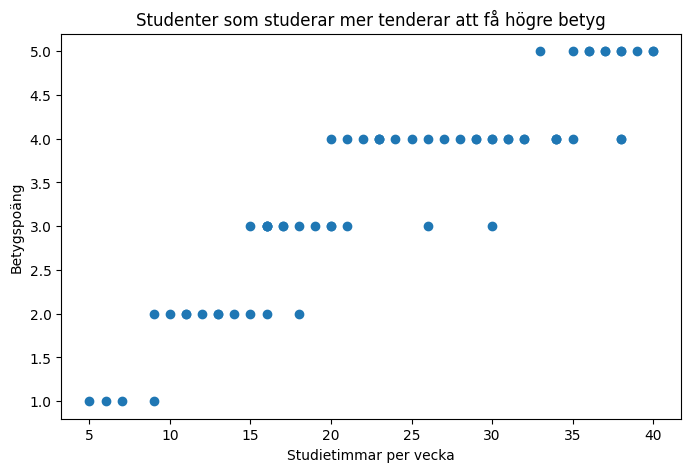

In [126]:
plt.figure(figsize=(8, 5))

plt.scatter(df["Studietimmar"], df["Betygspoäng"])

plt.title("Studenter som studerar mer tenderar att få högre betyg")

plt.xlabel("Studietimmar per vecka")

plt.ylabel("Betygspoäng")

plt.show()

# Reflektion kring scatterdiagrammet

Scatterdiagrammet visar ett tydligt positivt samband mellan studietimmar och betygspoäng. Generellt verkar studenter som lägger fler timmar på studier också uppnå högre resultat.

Sambandet är dock inte helt perfekt. Det finns flera observationer där studenter med liknande studietid uppnår olika betygspoäng. Detta antyder att studietimmar inte är den enda faktorn som påverkar prestation, utan att även andra variabler som motivation, studieteknik eller tidigare kunskaper kan spela in.

Scatterdiagram valdes eftersom båda variablerna är numeriska och syftet var att undersöka relationen mellan dem. Diagramtypen gör det möjligt att identifiera både övergripande trender och avvikande datapunkter i datasetet.

Visualiseringen gör det också tydligt hur svårt det är att dra absoluta slutsatser från enbart tabeller och statistik. Genom att plotta datan blir mönster och variationer betydligt lättare att upptäcka.